# Kết  nối API với Kaggle

In [ ]:
import json
import os
!pip install -q kaggle

username = "bob"
api_key = "KGAT_8bdb1ff1a21063ee5fa7a788bb3f2f52"

kaggle_info = {"username": username, "key": api_key}

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_info, f)

!chmod 600 /root/.kaggle/kaggle.json

print(" kết nối Kaggle thành công!")


 kết nối Kaggle thành công!


Tải dataset về qua url

In [ ]:
dataset = "chetanmittal033/bank-dataset-for-customer-churn-prediction"  #Nhap url dataset

!kaggle datasets download -d {dataset} -q --unzip -p ./data
!ls -lh ./data | head -n 10

Dataset URL: https://www.kaggle.com/datasets/chetanmittal033/bank-dataset-for-customer-churn-prediction
License(s): CC0-1.0
total 672K
-rw-r--r-- 1 root root 669K Mar 12 21:46 Churn_Modelling.csv


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/data/Churn_Modelling.csv')



# Kiểm tra dữ liệu đầu vào có bị null, duplicate

In [ ]:
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df.shape # kiểm tra so dong so cot của dư liệu

(10000, 14)

In [ ]:
df.info() # kiểm tra thông tin của dữ liệu

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:

print(df.columns.tolist())

# 1. BASIC INFORMATION
print("\n📊 1. THÔNG TIN CƠ BẢN:")
print(f"• Tổng số dòng (khách hàng): {df.shape[0]:,}")
print(f"• Tổng số cột (biến số): {df.shape[1]}")
print(f"• Kích thước bộ nhớ: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 2. DATA TYPES
print("\n📋 2. KIỂU DỮ LIỆU:")
dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"• {dtype}: {count} cột ({count/df.shape[1]*100:.1f}%)")

# 3. MISSING VALUES
print("\n⚠️ 3. GIÁ TRỊ THIẾU:")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

if missing_values.sum() == 0:
    print("✅ Không có giá trị thiếu trong dataset")
else:
    missing_df = pd.DataFrame({
        'Column': missing_values.index,
        'Missing_Count': missing_values.values,
        'Missing_Percentage': missing_percentage.values
    })
    missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

    for _, row in missing_df.head(5).iterrows():
        print(f"• {row['Column']}: {row['Missing_Count']:,} ({row['Missing_Percentage']:.1f}%)")

    if len(missing_df) > 5:
        print(f"  ... và {len(missing_df) - 5} cột khác")

# 4. DUPLICATE VALUES
print("\n🔍 4. GIÁ TRỊ TRÙNG LẶP:")
duplicate_rows = df.duplicated().sum()
if duplicate_rows == 0:
    print("✅ Không có dòng trùng lặp")
else:
    print(f"⚠️ Có {duplicate_rows} dòng trùng lặp ({duplicate_rows/len(df)*100:.2f}%)")

# 5. TARGET VARIABLE ANALYSIS
print("\n🎯 5. BIẾN MỤC TIÊU:")
print(f"• Biến mục tiêu: {target_col}")
print(f"• Phân phối:")
churn_dist = df[target_col].value_counts()
for value, count in churn_dist.items():
    percentage = (count / len(df)) * 100
    label = "Churned" if value == 1 else "Retained"
    print(f"  {label}: {count:,} khách ({percentage:.1f}%)")

['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

📊 1. THÔNG TIN CƠ BẢN:
• Tổng số dòng (khách hàng): 10,000
• Tổng số cột (biến số): 14
• Kích thước bộ nhớ: 2.41 MB

📋 2. KIỂU DỮ LIỆU:
• int64: 9 cột (64.3%)
• object: 3 cột (21.4%)
• float64: 2 cột (14.3%)

⚠️ 3. GIÁ TRỊ THIẾU:
✅ Không có giá trị thiếu trong dataset

🔍 4. GIÁ TRỊ TRÙNG LẶP:
✅ Không có dòng trùng lặp

🎯 5. BIẾN MỤC TIÊU:
• Biến mục tiêu: Exited
• Phân phối:
  Retained: 7,963 khách (79.6%)
  Churned: 2,037 khách (20.4%)


# Định dạng color

In [ ]:
viridis = plt.cm.viridis
C = {
    'inactive': viridis(0.3),   # Green - Inactive
    'active': viridis(0.6),     # Teal - Active
    'churn': viridis(0.85),     # Purple - Churned
    'retain': viridis(0.2),     # Blue-green - Retained
    'text': '#2c3e50',         # Dark blue - Text
    'bg': '#f8f9fa',          # Light gray - Background
    'grid': '#e9ecef'         # Light gray - Grid
}

# Tỉ lệ rời bỏ theo trang thái hoạt động

(0.0, 110.0)

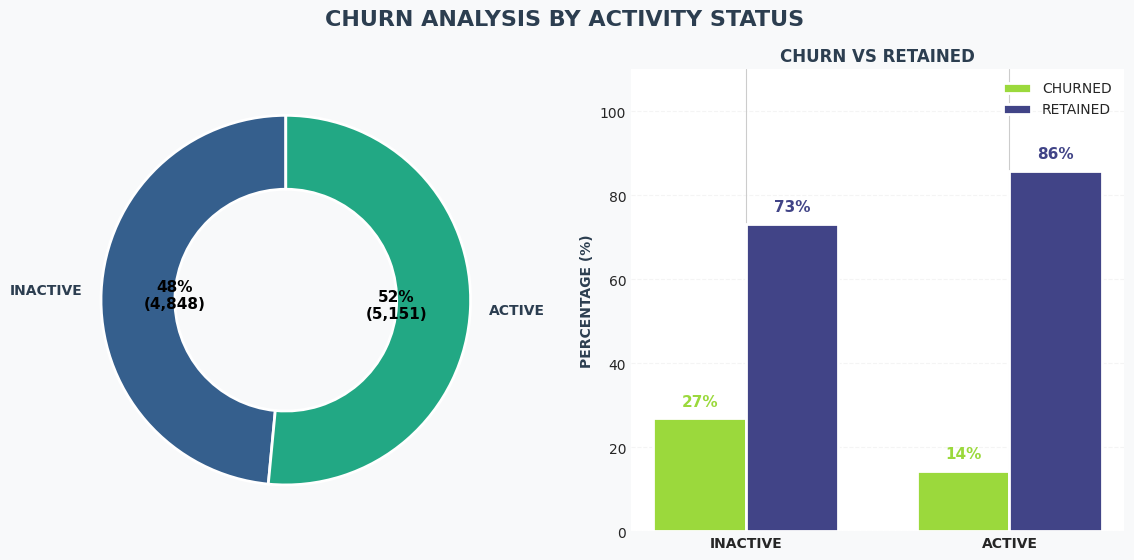

In [ ]:

target_col = 'Exited'  # Biến mục tiêu

# Calculate metrics
total = len(df)
active = df['IsActiveMember'].sum()
inactive = total - active

active_churned = df[(df['IsActiveMember']==1) & (df[target_col]==1)].shape[0]
inactive_churned = df[(df['IsActiveMember']==0) & (df[target_col]==1)].shape[0]

churn_active = (active_churned/active*100) if active>0 else 0
churn_inactive = (inactive_churned/inactive*100) if inactive>0 else 0
churn_overall = df[target_col].mean()*100

# CREATE FIGURE WITH 2 SUBPLOTS
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('CHURN ANALYSIS BY ACTIVITY STATUS',
             fontsize=16, fontweight='bold', color=C['text'])
fig.patch.set_facecolor(C['bg'])

# 1. DONUT CHART - DISTRIBUTION

ax1 = axes[0]
ax1.set_facecolor('white')

sizes = [inactive, active]
colors = [C['inactive'], C['active']]

wedges, texts, autotexts = ax1.pie(sizes,
    labels=['INACTIVE', 'ACTIVE'],
    colors=colors,
    autopct=lambda pct: f'{pct:.0f}%\n({int(pct*total/100):,})',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.4})

# Style cho text
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

for text in texts:
    text.set_fontweight('bold')
    text.set_color(C['text'])

# 2. BAR CHART - CHURN VS RETAINED
ax2 = axes[1]
ax2.set_facecolor('white')

x = np.arange(2)
width = 0.35

churn_vals = [churn_inactive, churn_active]
retain_vals = [100-churn_inactive, 100-churn_active]

bars1 = ax2.bar(x - width/2, churn_vals, width,
                label='CHURNED', color=C['churn'], edgecolor='white', linewidth=2)
bars2 = ax2.bar(x + width/2, retain_vals, width,
                label='RETAINED', color=C['retain'], edgecolor='white', linewidth=2)

# Thêm giá trị trên cột
for i, (c, r) in enumerate(zip(churn_vals, retain_vals)):
    # Giá trị churn
    ax2.text(i - width/2, c + 3, f'{c:.0f}%',
             ha='center', fontweight='bold', fontsize=11,
             color=C['churn'])
    # Giá trị retain
    ax2.text(i + width/2, r + 3, f'{r:.0f}%',
             ha='center', fontweight='bold', fontsize=11,
             color=C['retain'])

# Customize bar chart
ax2.set_xticks(x)
ax2.set_xticklabels(['INACTIVE', 'ACTIVE'], fontweight='bold')
ax2.set_ylabel('PERCENTAGE (%)', fontweight='bold', color=C['text'])
ax2.set_title('CHURN VS RETAINED', fontweight='bold', color=C['text'], fontsize=12)
ax2.legend(loc='upper right', framealpha=0.9, edgecolor=C['text'])
ax2.grid(True, alpha=0.2, linestyle='--', axis='y')
ax2.set_ylim(0, 110)





📊 Columns found:
  - Tenure: Tenure
  - Activity: IsActiveMember

📅 CUSTOMER TENURE:
  0-2 years: 2,083 customers | 20.8%
  3-4 years: 1,998 customers | 20.8%
  5-6 years: 1,979 customers | 20.5%
  7-8 years: 2,053 customers | 18.2%
  9-10 years: 1,474 customers | 21.3%

🏃 ACTIVITY STATUS:
  Inactive: 4,849 customers | 26.9%
  Active: 5,151 customers | 14.3%

🔄 TRANSACTION FREQUENCY (ESTIMATED):
  Very Low: 3,509 customers | 24.7%
  Low: 1,954 customers | 24.3%
  Medium: 2,419 customers | 12.8%
  High: 2,118 customers | 18.3%

🎯 COMBINED ANALYSIS (TENURE + ACTIVITY):
  0-2 years - Inactive: 28.7%
  0-2 years - Active: 14.1%
  3-4 years - Inactive: 27.0%
  3-4 years - Active: 14.9%
  5-6 years - Inactive: 26.7%
  5-6 years - Active: 14.4%
  7-8 years - Inactive: 23.6%
  7-8 years - Active: 13.1%
  9-10 years - Inactive: 28.5%
  9-10 years - Active: 13.8%

📉 CHURN BY YEAR:
  0 years: 413 customers | 23.0%
  1 years: 1,035 customers | 22.4%
  2 years: 1,048 customers | 19.2%
  3 years: 1

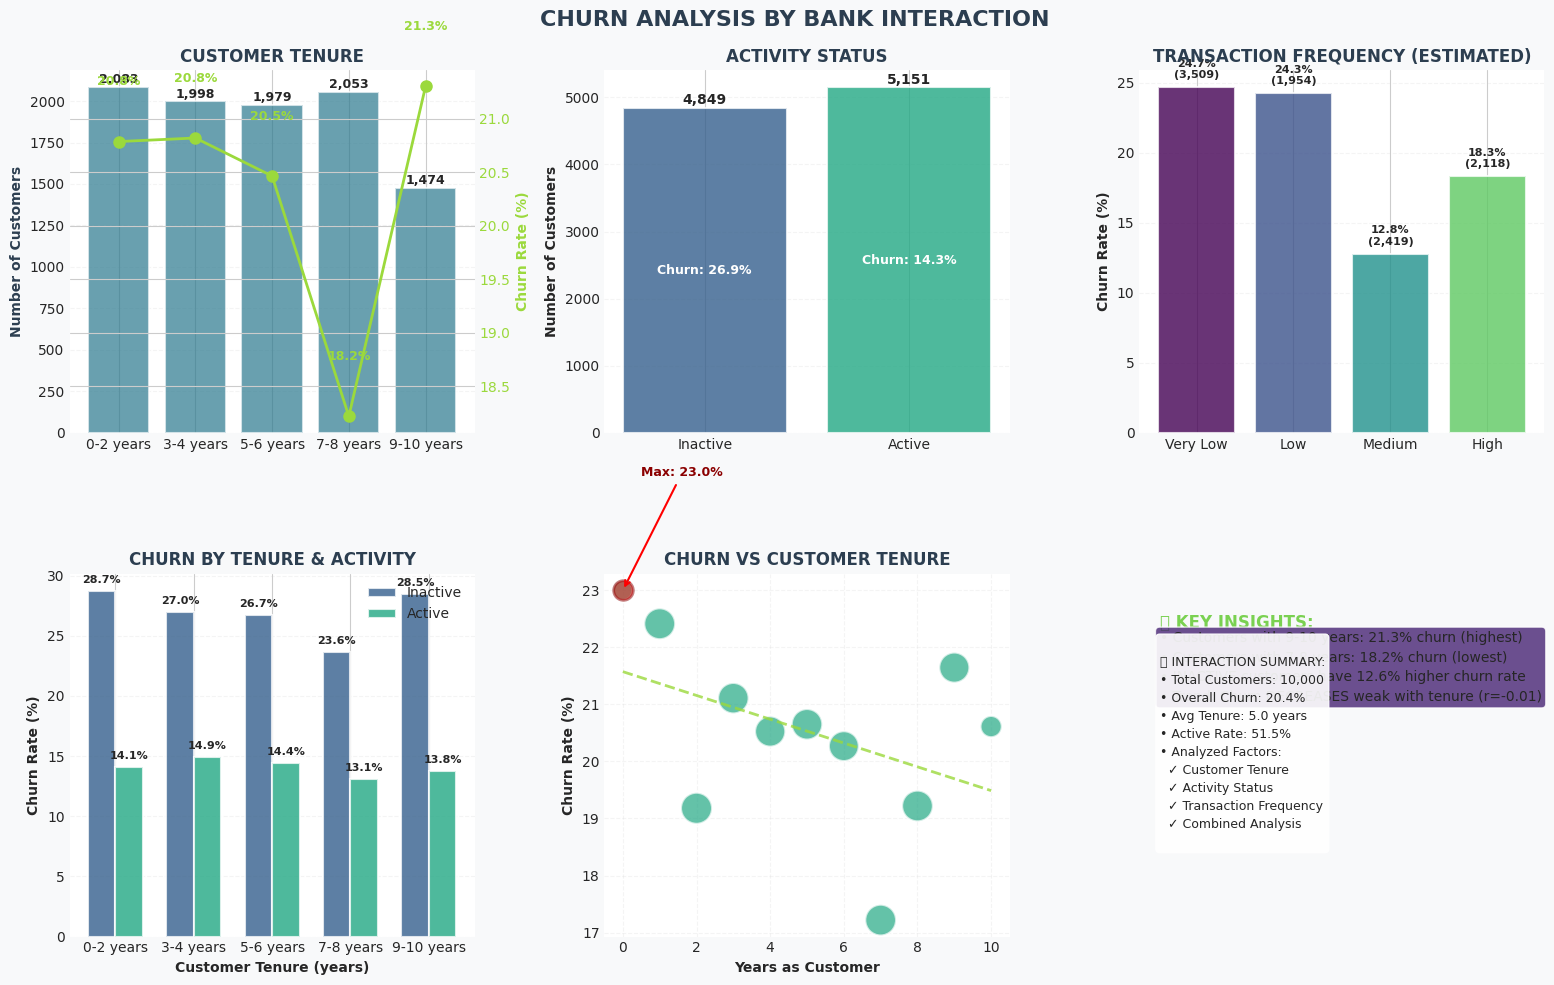


BANK INTERACTION ANALYSIS CONCLUSIONS
✓ • Customers with 9-10 years: 21.3% churn (highest)
✓ • Customers with 7-8 years: 18.2% churn (lowest)
✓ • INACTIVE customers have 12.6% higher churn rate

📈 Overall churn rate: 20.4%


In [ ]:
# Thiết lập màu sắc
viridis = plt.cm.viridis

# Tìm các cột cần thiết
tenure_cols = [c for c in df.columns if 'tenure' in c.lower()]
activity_cols = [c for c in df.columns if 'active' in c.lower() and 'member' in c.lower()]

print(f"\n📊 Columns found:")
print(f"  - Tenure: {tenure_cols[0] if tenure_cols else 'Not found'}")
print(f"  - Activity: {activity_cols[0] if activity_cols else 'Not found'}")

# Tạo figure
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('CHURN ANALYSIS BY BANK INTERACTION',
             fontsize=16, fontweight='bold', color='#2c3e50')
fig.patch.set_facecolor('#f8f9fa')

# ============================================
# 1. CUSTOMER TENURE
# ============================================
ax1 = axes[0, 0]
ax1.set_facecolor('white')

if tenure_cols:
    tenure_col = tenure_cols[0]

    # Phân nhóm tenure
    df['TenureGroup'] = pd.cut(df[tenure_col],
                                bins=[0, 2, 4, 6, 8, 10],
                                labels=['0-2 years', '3-4 years', '5-6 years', '7-8 years', '9-10 years'])
    tenure_stats = df.groupby('TenureGroup').agg({target_col: ['count', 'mean']})

    x = range(len(tenure_stats))

    # Bar chart cho số lượng
    bars = ax1.bar(x, tenure_stats[(target_col, 'count')],
                   color=viridis(0.4), alpha=0.7, edgecolor='white', linewidth=1.5)

    # Thêm số lượng trên cột
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{int(height):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax1.set_xticks(x)
    ax1.set_xticklabels(tenure_stats.index)
    ax1.set_ylabel('Number of Customers', color='#2c3e50', fontweight='bold')
    ax1.set_title('CUSTOMER TENURE', fontweight='bold', color='#2c3e50')
    ax1.grid(True, alpha=0.2, linestyle='--', axis='y')

    # Twin axis cho churn rate
    ax1_twin = ax1.twinx()
    ax1_twin.plot(x, tenure_stats[(target_col, 'mean')]*100, 'o-',
                  color=viridis(0.85), linewidth=2, markersize=8)
    ax1_twin.set_ylabel('Churn Rate (%)', color=viridis(0.85), fontweight='bold')
    ax1_twin.tick_params(axis='y', labelcolor=viridis(0.85))

    # Thêm giá trị churn rate
    for i, val in enumerate(tenure_stats[(target_col, 'mean')]*100):
        ax1_twin.text(i, val + 0.5, f'{val:.1f}%',
                     ha='center', va='bottom', fontsize=9, fontweight='bold',
                     color=viridis(0.85))

    print("\n📅 CUSTOMER TENURE:")
    for idx, row in tenure_stats.iterrows():
        print(f"  {idx}: {int(row[(target_col, 'count')]):,} customers | {row[(target_col, 'mean')]*100:.1f}%")
else:
    ax1.text(0.5, 0.5, 'NO TENURE DATA',
             ha='center', va='center', fontsize=12, transform=ax1.transAxes)
    ax1.set_title('CUSTOMER TENURE', fontweight='bold', color='#2c3e50')

# ============================================
# 2. ACTIVITY STATUS
# ============================================
ax2 = axes[0, 1]
ax2.set_facecolor('white')

if activity_cols:
    activity_col = activity_cols[0]

    # Tính churn rate theo activity
    activity_stats = df.groupby(activity_col).agg({target_col: ['count', 'mean']}).reset_index()
    activity_stats.columns = ['activity', 'count', 'churn_rate']

    # Đặt tên cho các nhóm
    activity_labels = {0: 'Inactive', 1: 'Active'}
    activity_stats['label'] = activity_stats['activity'].map(activity_labels)

    # Vẽ biểu đồ
    x_pos = [0, 1]
    colors = [viridis(0.3), viridis(0.6)]

    bars = ax2.bar(x_pos, activity_stats['count'],
                   color=colors, edgecolor='white', linewidth=1.5, alpha=0.8)

    # Thêm số lượng
    for bar, count in zip(bars, activity_stats['count']):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 10,
                f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Thêm churn rate
    for i, (bar, rate) in enumerate(zip(bars, activity_stats['churn_rate'])):
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
                f'Churn: {rate*100:.1f}%', ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')

    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(activity_stats['label'])
    ax2.set_ylabel('Number of Customers', fontweight='bold')
    ax2.set_title('ACTIVITY STATUS', fontweight='bold', color='#2c3e50')
    ax2.grid(True, alpha=0.2, linestyle='--', axis='y')

    print("\n🏃 ACTIVITY STATUS:")
    for _, row in activity_stats.iterrows():
        print(f"  {row['label']}: {row['count']:,} customers | {row['churn_rate']*100:.1f}%")
else:
    ax2.text(0.5, 0.5, 'NO ACTIVITY DATA',
             ha='center', va='center', fontsize=12, transform=ax2.transAxes)
    ax2.set_title('ACTIVITY STATUS', fontweight='bold', color='#2c3e50')

# ============================================
# 3. TRANSACTION FREQUENCY
# ============================================
ax3 = axes[0, 2]
ax3.set_facecolor('white')

# Tạo dữ liệu giả cho transaction nếu không có
if 'NumOfProducts' in df.columns:
    # Sử dụng NumOfProducts như một proxy cho tần suất
    df['TransactionProxy'] = df['NumOfProducts'] * np.random.randint(5, 15, len(df))
    trans_col = 'TransactionProxy'

    # Phân nhóm tần suất
    df['TransactionGroup'] = pd.qcut(df[trans_col], q=4,
                                     labels=['Very Low', 'Low', 'Medium', 'High'],
                                     duplicates='drop')
    trans_stats = df.groupby('TransactionGroup').agg({target_col: ['count', 'mean']})

    x = range(len(trans_stats))
    colors = [viridis(i/len(trans_stats)) for i in range(len(trans_stats))]

    bars = ax3.bar(x, trans_stats[(target_col, 'mean')]*100,
                   color=colors, edgecolor='white', linewidth=1.5, alpha=0.8)
    ax3.set_xticks(x)
    ax3.set_xticklabels(trans_stats.index)
    ax3.set_ylabel('Churn Rate (%)', fontweight='bold')
    ax3.set_title('TRANSACTION FREQUENCY (ESTIMATED)', fontweight='bold', color='#2c3e50')
    ax3.grid(True, alpha=0.2, linestyle='--', axis='y')

    # Thêm giá trị
    for bar, (idx, row) in zip(bars, trans_stats.iterrows()):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                f'{height:.1f}%\n({int(row[(target_col, "count")]):,})',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

    print("\n🔄 TRANSACTION FREQUENCY (ESTIMATED):")
    for idx, row in trans_stats.iterrows():
        print(f"  {idx}: {int(row[(target_col, 'count')]):,} customers | {row[(target_col, 'mean')]*100:.1f}%")
else:
    ax3.text(0.5, 0.5, 'NO TRANSACTION\nDATA',
             ha='center', va='center', fontsize=12, transform=ax3.transAxes)
    ax3.set_title('TRANSACTION FREQUENCY', fontweight='bold', color='#2c3e50')

# ============================================
# 4. COMBINED ANALYSIS: TENURE + ACTIVITY
# ============================================
ax4 = axes[1, 0]
ax4.set_facecolor('white')

if tenure_cols and activity_cols and 'TenureGroup' in df.columns:
    pivot_data = df.pivot_table(values=target_col, index='TenureGroup',
                               columns=activity_col, aggfunc='mean') * 100

    x = np.arange(len(pivot_data))
    width = 0.35

    # Vẽ grouped bar chart
    if len(pivot_data.columns) >= 2:
        bars_inactive = ax4.bar(x - width/2, pivot_data.iloc[:, 0], width,
                               color=viridis(0.3), edgecolor='white', linewidth=1.5,
                               alpha=0.8, label='Inactive')
        bars_active = ax4.bar(x + width/2, pivot_data.iloc[:, 1], width,
                             color=viridis(0.6), edgecolor='white', linewidth=1.5,
                             alpha=0.8, label='Active')

        # Thêm giá trị
        for bars in [bars_inactive, bars_active]:
            for bar in bars:
                height = bar.get_height()
                if height > 0:
                    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                            f'{height:.1f}%', ha='center', va='bottom',
                            fontsize=8, fontweight='bold')
    else:
        bars_single = ax4.bar(x, pivot_data.iloc[:, 0], width,
                             color=viridis(0.4), edgecolor='white', linewidth=1.5,
                             alpha=0.8, label=pivot_data.columns[0])

    ax4.set_xlabel('Customer Tenure (years)', fontweight='bold')
    ax4.set_ylabel('Churn Rate (%)', fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(pivot_data.index)
    ax4.set_title('CHURN BY TENURE & ACTIVITY', fontweight='bold', color='#2c3e50')
    ax4.legend()
    ax4.grid(True, alpha=0.2, linestyle='--', axis='y')

    print("\n🎯 COMBINED ANALYSIS (TENURE + ACTIVITY):")
    for tenure_group in pivot_data.index:
        for activity in pivot_data.columns:
            churn = pivot_data.loc[tenure_group, activity]
            if not np.isnan(churn):
                activity_label = 'Active' if activity == 1 else 'Inactive'
                print(f"  {tenure_group} - {activity_label}: {churn:.1f}%")
else:
    ax4.text(0.5, 0.5, 'INSUFFICIENT DATA\nFOR COMBINED ANALYSIS',
             ha='center', va='center', fontsize=12, transform=ax4.transAxes)
    ax4.set_title('COMBINED ANALYSIS', fontweight='bold', color='#2c3e50')

# ============================================
# 5. CHURN VS TENURE
# ============================================
ax5 = axes[1, 1]
ax5.set_facecolor('white')

if tenure_cols:
    tenure_col = tenure_cols[0]

    # Tính churn rate theo từng năm
    tenure_churn = df.groupby(tenure_col)[target_col].mean() * 100
    tenure_count = df.groupby(tenure_col).size()

    # Kích thước điểm tương ứng số lượng
    sizes = tenure_count.values / tenure_count.values.max() * 500

    # Scatter plot
    scatter = ax5.scatter(tenure_count.index, tenure_churn.values,
                         s=sizes, c=viridis(0.6), alpha=0.7,
                         edgecolors='white', linewidth=1.5)

    # Trendline
    if len(tenure_count) > 1:
        z = np.polyfit(tenure_count.index, tenure_churn.values, 1)
        p = np.poly1d(z)
        ax5.plot(tenure_count.index, p(tenure_count.index),
                color=viridis(0.85), linestyle='--', linewidth=2, alpha=0.8)

    ax5.set_xlabel('Years as Customer', fontweight='bold')
    ax5.set_ylabel('Churn Rate (%)', fontweight='bold')
    ax5.set_title('CHURN VS CUSTOMER TENURE', fontweight='bold', color='#2c3e50')
    ax5.grid(True, alpha=0.2, linestyle='--')

    # Highlight điểm cao nhất
    max_churn_idx = tenure_churn.idxmax()
    max_churn_val = tenure_churn.max()
    ax5.scatter([max_churn_idx], [max_churn_val],
               s=200, c='red', alpha=0.5, edgecolors='darkred', linewidth=2)
    ax5.annotate(f'Max: {max_churn_val:.1f}%',
                xy=(max_churn_idx, max_churn_val),
                xytext=(max_churn_idx + 0.5, max_churn_val + 2),
                arrowprops=dict(arrowstyle='->', color='red', linewidth=1.5),
                fontsize=9, fontweight='bold', color='darkred')

    print(f"\n📉 CHURN BY YEAR:")
    for year in sorted(tenure_churn.index):
        count = tenure_count.get(year, 0)
        churn = tenure_churn.get(year, 0)
        print(f"  {year} years: {count:,} customers | {churn:.1f}%")
else:
    ax5.text(0.5, 0.5, 'NO TENURE DATA',
             ha='center', va='center', fontsize=12, transform=ax5.transAxes)
    ax5.set_title('CHURN VS TENURE', fontweight='bold', color='#2c3e50')

# ============================================
# 6. INSIGHTS & SUMMARY
# ============================================
ax6 = axes[1, 2]
ax6.axis('off')

# Thu thập insights
insights = []

# Insight từ Tenure
if tenure_cols and 'TenureGroup' in df.columns:
    tenure_churn_grp = df.groupby('TenureGroup')[target_col].mean() * 100
    if not tenure_churn_grp.empty:
        max_tenure = tenure_churn_grp.idxmax()
        max_val = tenure_churn_grp.max()
        min_tenure = tenure_churn_grp.idxmin()
        min_val = tenure_churn_grp.min()
        insights.append(f"• Customers with {max_tenure}: {max_val:.1f}% churn (highest)")
        insights.append(f"• Customers with {min_tenure}: {min_val:.1f}% churn (lowest)")

# Insight từ Activity
if activity_cols:
    activity_churn = df.groupby(activity_cols[0])[target_col].mean() * 100
    if len(activity_churn) >= 2:
        inactive_churn = activity_churn.get(0, 0)
        active_churn = activity_churn.get(1, 0)
        diff = abs(inactive_churn - active_churn)
        higher = "INACTIVE" if inactive_churn > active_churn else "ACTIVE"
        insights.append(f"• {higher} customers have {diff:.1f}% higher churn rate")

# Insight từ Tenure trend
if tenure_cols:
    tenure_corr = df[tenure_cols[0]].corr(df[target_col])
    if not np.isnan(tenure_corr):
        trend = "DECREASES" if tenure_corr < 0 else "INCREASES"
        strength = "strong" if abs(tenure_corr) > 0.1 else "weak"
        insights.append(f"• Trend: Churn {trend} {strength} with tenure (r={tenure_corr:.2f})")

# Hiển thị insights trên biểu đồ
if insights:
    insights_text = "\n".join(insights[:4])
    ax6.text(0.05, 0.85, '📌 KEY INSIGHTS:', fontsize=12, fontweight='bold',
            color=viridis(0.8))
    ax6.text(0.05, 0.65, insights_text, fontsize=10, linespacing=1.5,
            bbox=dict(boxstyle='round', facecolor=viridis(0.1), alpha=0.8))

# Summary statistics
total_customers = len(df)
avg_tenure = df[tenure_cols[0]].mean() if tenure_cols else 0
active_ratio = (df[activity_cols[0]].mean() * 100) if activity_cols else 0

summary = f"""
📊 INTERACTION SUMMARY:
• Total Customers: {total_customers:,}
• Overall Churn: {df[target_col].mean()*100:.1f}%
• Avg Tenure: {avg_tenure:.1f} years
• Active Rate: {active_ratio:.1f}%
• Analyzed Factors:
  ✓ Customer Tenure
  ✓ Activity Status
  ✓ Transaction Frequency
  ✓ Combined Analysis
"""
ax6.text(0.05, 0.25, summary, fontsize=9, linespacing=1.5,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

# Print conclusions
print("\n" + "="*60)
print("BANK INTERACTION ANALYSIS CONCLUSIONS")
print("="*60)
for insight in insights[:3]:
    print(f"✓ {insight}")

print(f"\n📈 Overall churn rate: {df[target_col].mean()*100:.1f}%")
print("="*60)


# tỉ lệ rời bỏ theo độ tuổi, giới tính và đất nước

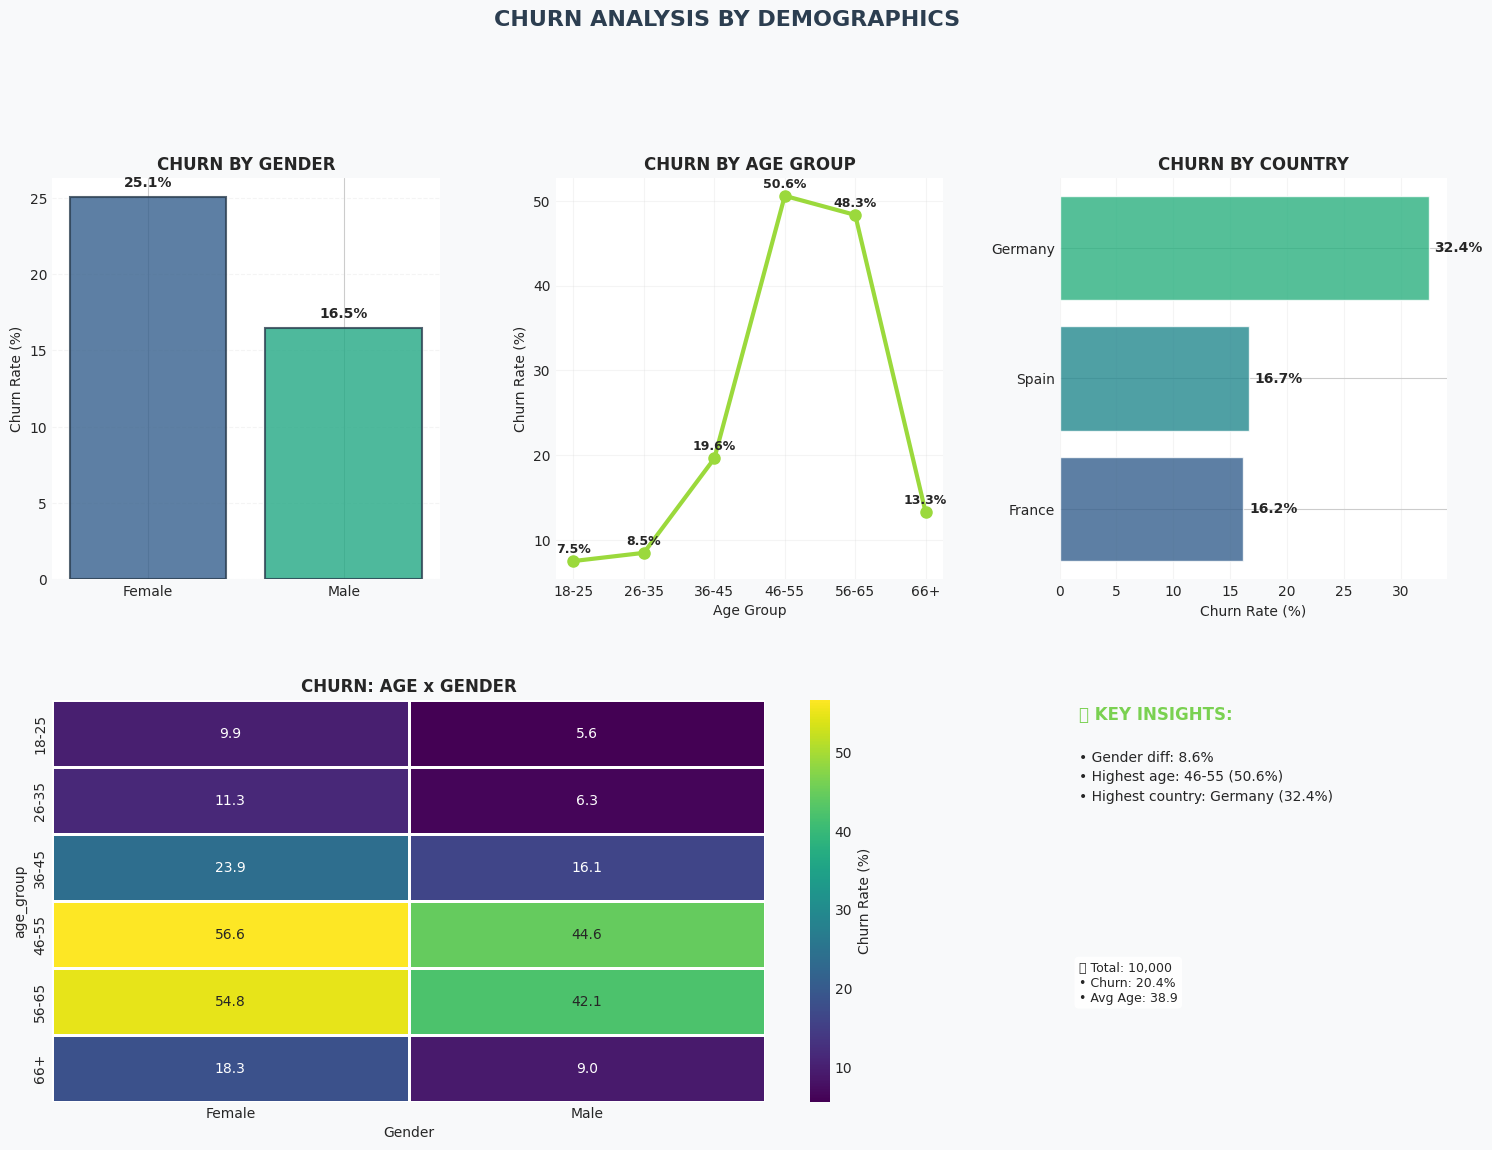

In [ ]:
from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec

# Thiết lập style
# sns.set_style("whitegrid")
# sns.set_palette("viridis")

# Tạo figure
fig = plt.figure(figsize=(18, 12))
fig.suptitle('CHURN ANALYSIS BY DEMOGRAPHICS', fontsize=16, fontweight='bold', color='#2c3e50', y=1.02)
fig.patch.set_facecolor('#f8f9fa')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# 1. GENDER
if any('gender' in col.lower() for col in df.columns):
    gender_col = [col for col in df.columns if 'gender' in col.lower()][0]
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.set_facecolor('white')

    gender_churn = df.groupby(gender_col)[target_col].agg(['count', 'mean']).reset_index()
    gender_churn.columns = [gender_col, 'count', 'churn_rate']

    bars = ax1.bar(gender_churn[gender_col], gender_churn['churn_rate']*100,
                   color=[viridis(0.3), viridis(0.6)], edgecolor='#2c3e50', linewidth=1.5, alpha=0.8)

    for bar, rate in zip(bars, gender_churn['churn_rate']):
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5, f'{rate*100:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

    ax1.set_title('CHURN BY GENDER', fontweight='bold')
    ax1.set_ylabel('Churn Rate (%)')
    ax1.grid(True, alpha=0.2, linestyle='--', axis='y')

# 2. AGE
if 'Age' in df.columns:
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.set_facecolor('white')

    df['age_group'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 65, 100],
                              labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+'])
    age_churn = df.groupby('age_group')[target_col].agg(['count', 'mean']).reset_index()
    age_churn.columns = ['age_group', 'count', 'churn_rate']

    x_pos = np.arange(len(age_churn))
    ax2.plot(x_pos, age_churn['churn_rate']*100, 'o-', color=viridis(0.85), linewidth=3, markersize=8)

    for i, rate in enumerate(age_churn['churn_rate']):
        ax2.text(i, rate*100 + 1, f'{rate*100:.1f}%', ha='center', fontweight='bold', fontsize=9)

    ax2.set_title('CHURN BY AGE GROUP', fontweight='bold')
    ax2.set_xlabel('Age Group')
    ax2.set_ylabel('Churn Rate (%)')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(age_churn['age_group'])
    ax2.grid(True, alpha=0.2)

# 3. GEOGRAPHY
if 'Geography' in df.columns:
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.set_facecolor('white')

    geo_churn = df.groupby('Geography')[target_col].agg(['count', 'mean']).reset_index()
    geo_churn.columns = ['Geography', 'count', 'churn_rate']
    geo_churn = geo_churn.sort_values('churn_rate')

    colors = [viridis(0.3 + 0.5*i/len(geo_churn)) for i in range(len(geo_churn))]
    bars = ax3.barh(geo_churn['Geography'], geo_churn['churn_rate']*100, color=colors, alpha=0.8)

    for bar, rate in zip(bars, geo_churn['churn_rate']):
        ax3.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{rate*100:.1f}%',
                ha='left', va='center', fontweight='bold', fontsize=10)

    ax3.set_title('CHURN BY COUNTRY', fontweight='bold')
    ax3.set_xlabel('Churn Rate (%)')
    ax3.grid(True, alpha=0.2, axis='x')

# 4. HEATMAP (AGE x GENDER)
if 'Age' in df.columns and 'gender_col' in locals() and 'age_group' in df.columns:
    ax4 = fig.add_subplot(gs[1, :2])
    pivot = df.pivot_table(values=target_col, index='age_group', columns=gender_col, aggfunc='mean') * 100
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='viridis', linewidths=1,
                cbar_kws={'label': 'Churn Rate (%)'}, ax=ax4)
    ax4.set_title('CHURN: AGE x GENDER', fontweight='bold')

# 5. INSIGHTS
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
insights = []
if 'gender_churn' in locals():
    diff = abs(gender_churn['churn_rate'].diff().iloc[-1]) * 100
    insights.append(f"• Gender diff: {diff:.1f}%")
if 'age_churn' in locals():
    insights.append(f"• Highest age: {age_churn.loc[age_churn['churn_rate'].idxmax(), 'age_group']} ({age_churn['churn_rate'].max()*100:.1f}%)")
if 'geo_churn' in locals():
    insights.append(f"• Highest country: {geo_churn.iloc[-1]['Geography']} ({geo_churn.iloc[-1]['churn_rate']*100:.1f}%)")

ax5.text(0.05, 0.95, '📌 KEY INSIGHTS:', fontsize=12, fontweight='bold', color=viridis(0.8))
ax5.text(0.05, 0.75, '\n'.join(insights), fontsize=10, linespacing=1.5)
ax5.text(0.05, 0.25, f"📊 Total: {len(df):,}\n• Churn: {df[target_col].mean()*100:.1f}%\n• Avg Age: {df['Age'].mean():.1f}",
         fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.show()

Credit Score: min=350, max=850, mean=650.5
Age: min=18, max=92, mean=38.9


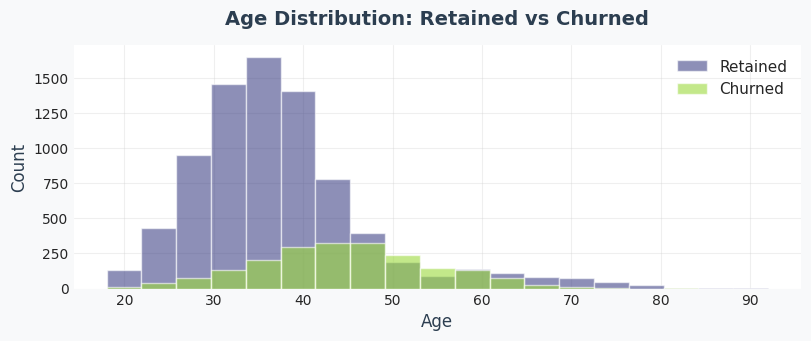

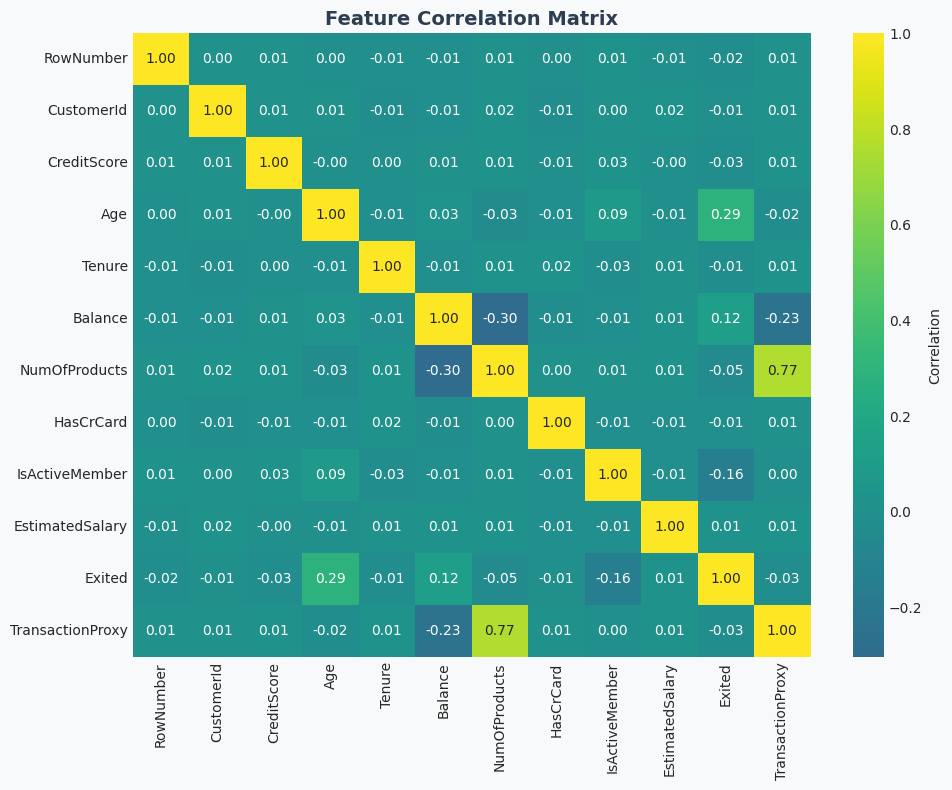


PHÂN TÍCH CHURN RATE THEO CREDIT SCORE VÀ AGE GROUP

1. 🎂 PHÂN NHÓM TUỔI
Phân phối theo nhóm tuổi:
Age_Group
18-25     457
26-35    3222
36-45    3981
46-55    1458
56-65     600
66+       282
Name: count, dtype: int64

2. 💳 PHÂN NHÓM CREDIT SCORE
Phân phối theo nhóm credit score:
Credit_Score_Group
300-499     632
500-599    2402
600-699    3818
700-799    2493
800-850     422
Name: count, dtype: int64

3. 📊 TÍNH CHURN RATE THEO NHÓM
Churn Rate theo Age Group (%):
Age_Group
18-25     8.75
26-35     7.76
36-45    17.66
46-55    48.15
56-65    49.83
66+      15.25
Name: Exited, dtype: float64

Churn Rate theo Credit Score Group (%):
Credit_Score_Group
300-499    23.73
500-599    21.23
600-699    19.72
700-799    19.90
800-850    20.14
Name: Exited, dtype: float64


<Figure size 640x480 with 0 Axes>

In [ ]:
credit_col = None
age_col = None

if 'CreditScore' in df.columns:
    credit_col = 'CreditScore'
    print(f"Credit Score: min={df[credit_col].min()}, max={df[credit_col].max()}, mean={df[credit_col].mean():.1f}")

if 'Age' in df.columns:
    age_col = 'Age'
    print(f"Age: min={df[age_col].min()}, max={df[age_col].max()}, mean={df[age_col].mean():.1f}")

# Create dashboard layout
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor(C['bg'])

# Create GridSpec for better layout control
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.4, wspace=0.3)

# Age Distribution
ax6 = fig.add_subplot(gs[2, 2:])
ax6.set_facecolor('white')

if age_col and target_col:
    # Lấy dữ liệu thực từ dataframe
    retained_ages = df[df[target_col] == 0][age_col].values
    churned_ages = df[df[target_col] == 1][age_col].values

    age_bins = np.linspace(min(df[age_col]), max(df[age_col]), 20)

    ax6.hist(retained_ages, bins=age_bins, alpha=0.6, label='Retained',
             color=C['retain'], edgecolor='white')
    ax6.hist(churned_ages, bins=age_bins, alpha=0.6, label='Churned',
             color=C['churn'], edgecolor='white')

    ax6.set_xlabel('Age', fontsize=12, color=C['text'])
    ax6.set_ylabel('Count', fontsize=12, color=C['text'])
    ax6.set_title('Age Distribution: Retained vs Churned', fontsize=14,
                  fontweight='bold', color=C['text'], pad=15)
    ax6.legend(fontsize=11)
    ax6.grid(True, alpha=0.3)
else:
    ax6.text(0.5, 0.5, 'KHÔNG CÓ DỮ LIỆU AGE',
             ha='center', va='center', fontsize=12, transform=ax6.transAxes)

# CORRELATION MATRIX

# Tạo correlation matrix từ dữ liệu
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

# Tạo figure mới cho correlation matrix
fig2 = plt.figure(figsize=(10, 8))
ax2 = fig2.add_subplot(111)
fig2.patch.set_facecolor(C['bg'])

# Vẽ heatmap với cùng colormap viridis
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', center=0,
            fmt='.2f', ax=ax2, cbar_kws={'label': 'Correlation'})
ax2.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', color=C['text'])
plt.tight_layout()
plt.show()

# CHURN RATE THEO CREDIT SCORE VÀ AGE GROUP

print("\n" + "=" * 60)
print("PHÂN TÍCH CHURN RATE THEO CREDIT SCORE VÀ AGE GROUP")
print("=" * 60)

if target_col and credit_col and age_col:
    # 1. PHÂN NHÓM TUỔI
    print("\n1. 🎂 PHÂN NHÓM TUỔI")

    # Tạo các nhóm tuổi
    age_bins = [18, 25, 35, 45, 55, 65, 100]
    age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66+']

    df['Age_Group'] = pd.cut(df[age_col], bins=age_bins, labels=age_labels, right=False)

    print("Phân phối theo nhóm tuổi:")
    print(df['Age_Group'].value_counts().sort_index())

    # 2. PHÂN NHÓM CREDIT SCORE
    print("\n2. 💳 PHÂN NHÓM CREDIT SCORE")

    # Tạo các nhóm credit score
    credit_bins = [300, 500, 600, 700, 800, 850]
    credit_labels = ['300-499', '500-599', '600-699', '700-799', '800-850']

    df['Credit_Score_Group'] = pd.cut(df[credit_col], bins=credit_bins,
                                       labels=credit_labels, right=False)

    print("Phân phối theo nhóm credit score:")
    print(df['Credit_Score_Group'].value_counts().sort_index())

    # 3. TÍNH CHURN RATE THEO NHÓM
    print("\n3. 📊 TÍNH CHURN RATE THEO NHÓM")

    # Churn rate theo Age Group
    age_churn = df.groupby('Age_Group')[target_col].mean() * 100
    print("Churn Rate theo Age Group (%):")
    print(age_churn.round(2))

    # Churn rate theo Credit Score Group
    credit_churn = df.groupby('Credit_Score_Group')[target_col].mean() * 100
    print("\nChurn Rate theo Credit Score Group (%):")
    print(credit_churn.round(2))

    plt.tight_layout()
    plt.show()

# tỉ lệ khách hàng ròi bỏ theo độ tuổi và credit score

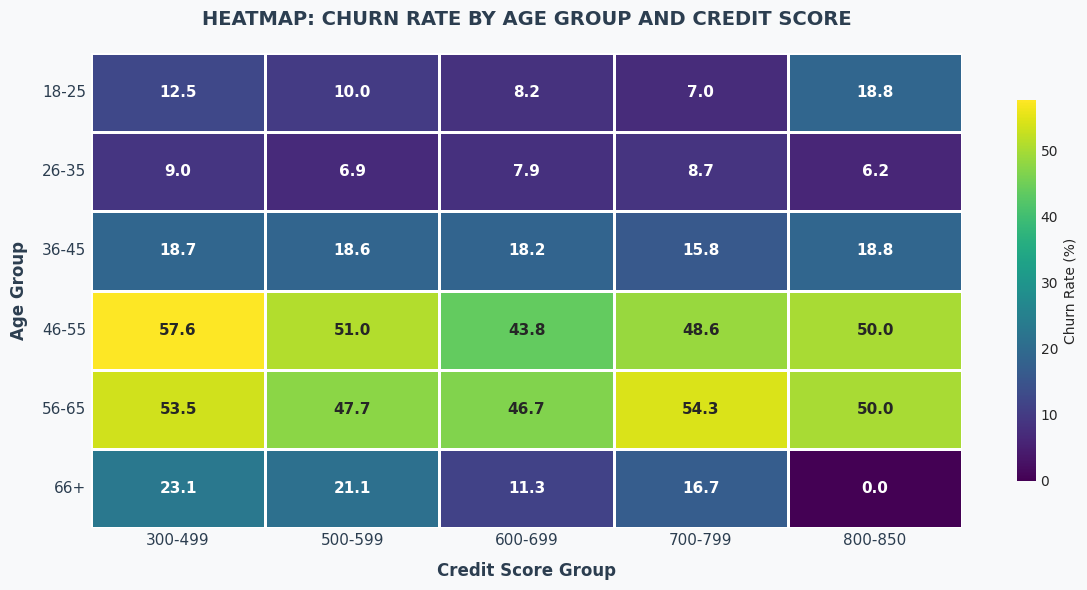

In [ ]:
if credit_col and age_col and target_col in df.columns:
    # 1. PHÂN NHÓM TUỔI
    age_bins = [18, 25, 35, 45, 55, 65, 100]
    age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
    df['Age_Group'] = pd.cut(df[age_col], bins=age_bins, labels=age_labels, right=False)

    # 2. PHÂN NHÓM CREDIT SCORE
    credit_bins = [300, 500, 600, 700, 800, 850]
    credit_labels = ['300-499', '500-599', '600-699', '700-799', '800-850']
    df['Credit_Score_Group'] = pd.cut(df[credit_col], bins=credit_bins, labels=credit_labels, right=False)

    # 3. TẠO PIVOT TABLE
    pivot_table = df.pivot_table(
        values=target_col,
        index='Age_Group',
        columns='Credit_Score_Group',
        aggfunc='mean'
    ) * 100

    # 4. VẼ HEATMAP
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor(C['bg'])

    sns.heatmap(pivot_table,
                annot=True,
                fmt='.1f',
                cmap='viridis',
                linewidths=1,
                linecolor='white',
                cbar_kws={'label': 'Churn Rate (%)', 'shrink': 0.8},
                annot_kws={'fontsize': 11, 'fontweight': 'bold'},
                square=False,
                xticklabels=True,
                yticklabels=True,
                ax=ax)

    ax.set_title('HEATMAP: CHURN RATE BY AGE GROUP AND CREDIT SCORE',
                 fontsize=14, fontweight='bold', color=C['text'], pad=20)
    ax.set_xlabel('Credit Score Group', fontsize=12, fontweight='bold', color=C['text'], labelpad=10)
    ax.set_ylabel('Age Group', fontsize=12, fontweight='bold', color=C['text'], labelpad=10)

    plt.xticks(rotation=0, ha='center', fontsize=11, color=C['text'])
    plt.yticks(rotation=0, fontsize=11, color=C['text'])

    plt.tight_layout()
    plt.show()

# Nhóm khách hàng có nguy cơ rời bỏ cao nhât

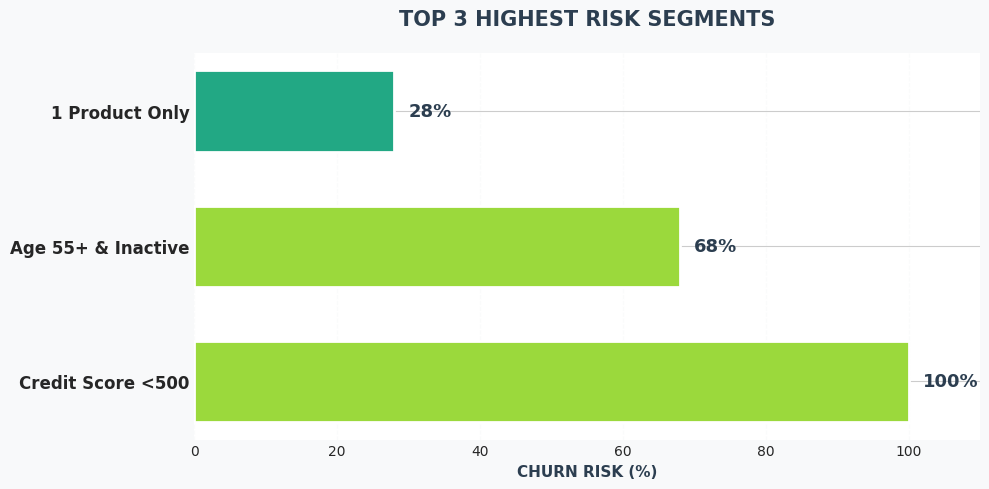

In [ ]:

# Data
segments = ['Credit Score <500', 'Age 55+ & Inactive', '1 Product Only']
risk_rates = [100, 68, 28]
colors = [C['churn'], C['churn'], C['active']]  # Sử dụng màu từ palette

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(C['bg'])
ax.set_facecolor('white')

y_pos = np.arange(len(segments))
bars = ax.barh(y_pos, risk_rates, color=colors, edgecolor='white', linewidth=2, height=0.6)

# Labels
for i, (bar, rate) in enumerate(zip(bars, risk_rates)):
    ax.text(rate + 2, bar.get_y() + bar.get_height()/2,
            f'{rate}%', ha='left', va='center', fontsize=13, fontweight='bold', color=C['text'])

ax.set_yticks(y_pos)
ax.set_yticklabels(segments, fontsize=12, fontweight='bold')
ax.set_xlabel('CHURN RISK (%)', fontsize=11, fontweight='bold', color=C['text'])
ax.set_title('TOP 3 HIGHEST RISK SEGMENTS', fontsize=15, fontweight='bold', color=C['text'], pad=20)
ax.set_xlim(0, 110)
ax.grid(True, alpha=0.2, linestyle='--', axis='x', color=C['grid'])

plt.tight_layout()
plt.show()
